## 

## scaling transient (7), ugyldige readings?

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import torch
import torch.nn as nn

In [154]:
df1 = pd.read_csv('data/7/WELL-00001_20170226220309.csv')
name = 'Well_1_2602'
path = f'../outputs/7/run4/{name}'

In [155]:
df1.head()

,timestamp,P-PDG,P-TPT,T-TPT,P-MON-CKP,T-JUS-CKP,P-JUS-CKGL,T-JUS-CKGL,QGL,class
0,2017-02-26 22:03:09.000000,0.0,13342350.0,118.1273,5390925.0,73.97794,3385812.0,NaN,0.0,0.0
1,2017-02-26 22:03:10.000000,0.0,13342390.0,118.1273,5390720.0,73.97781,3385812.0,NaN,0.0,0.0
2,2017-02-26 22:03:11.000000,0.0,13342430.0,118.1273,5390515.0,73.97768,3385812.0,NaN,0.0,0.0
3,2017-02-26 22:03:12.000000,0.0,13342470.0,118.1273,5390310.0,73.97756,3385812.0,NaN,0.0,0.0
4,2017-02-26 22:03:13.000000,0.0,13342510.0,118.1272,5390105.0,73.97743,3385812.0,NaN,0.0,0.0


In [156]:
df1.drop(columns=['timestamp','T-TPT', 'T-JUS-CKP', 'T-JUS-CKGL', 'P-JUS-CKGL', 'QGL'], inplace=True)

In [157]:
df1.head()

,P-PDG,P-TPT,P-MON-CKP,class
0,0.0,13342350.0,5390925.0,0.0
1,0.0,13342390.0,5390720.0,0.0
2,0.0,13342430.0,5390515.0,0.0
3,0.0,13342470.0,5390310.0,0.0
4,0.0,13342510.0,5390105.0,0.0


In [158]:
tmp = df1.rename(columns= {'P-PDG': 'Pump outlet pressure (Mean)', 'P-TPT': 'TS inlet pressure (Mean)', 'P-MON-CKP': 'TS outlet pressure (Mean)'})

In [159]:
tmp['Differential pressure (Mean)'] = tmp['TS inlet pressure (Mean)'] - tmp['TS outlet pressure (Mean)']
tmp['Pump to inlet DP'] = tmp['Pump outlet pressure (Mean)'] - tmp['TS inlet pressure (Mean)']
tmp['Total system DP'] = tmp['Pump outlet pressure (Mean)'] - tmp['TS outlet pressure (Mean)']

In [160]:
baseline = tmp.iloc[:60]

tmp['rel_tot_dp_change'] = tmp['Total system DP'] / baseline['Total system DP'].median()
tmp['rel_ts_dp_change'] = tmp['Differential pressure (Mean)'] / baseline['Differential pressure (Mean)'].median()
tmp['rel_p_ts_dp_change'] = tmp['Pump to inlet DP'] / baseline['Pump to inlet DP'].median()

In [161]:
tmp['Pressure_Ratio'] = (tmp['TS inlet pressure (Mean)'] - tmp['TS outlet pressure (Mean)']) / \
                           (tmp['Pump outlet pressure (Mean)'] - tmp['TS inlet pressure (Mean)'] + 1e-6)

base_ratio_val = tmp['Pressure_Ratio'].iloc[:60].median()
    
tmp['Relative_Ratio_Dev'] = (tmp['Pressure_Ratio'] / (base_ratio_val + 1e-6) - 1).abs()

In [162]:
tmp.head()

,Pump outlet pressure (Mean),TS inlet pressure (Mean),TS outlet pressure (Mean),class,Differential pressure (Mean),Pump to inlet DP,Total system DP,rel_tot_dp_change,rel_ts_dp_change,rel_p_ts_dp_change,Pressure_Ratio,Relative_Ratio_Dev
0,0.0,13342350.0,5390925.0,0.0,7951425.0,-13342350.0,-5390925.0,1.001123,0.999098,0.999915,-0.595954,0.000816
1,0.0,13342390.0,5390720.0,0.0,7951670.0,-13342390.0,-5390720.0,1.001085,0.999128,0.999918,-0.595970,0.000788
2,0.0,13342430.0,5390515.0,0.0,7951915.0,-13342430.0,-5390515.0,1.001047,0.999159,0.999921,-0.595987,0.000760
3,0.0,13342470.0,5390310.0,0.0,7952160.0,-13342470.0,-5390310.0,1.001009,0.999190,0.999924,-0.596004,0.000732
4,0.0,13342510.0,5390105.0,0.0,7952405.0,-13342510.0,-5390105.0,1.000971,0.999221,0.999927,-0.596020,0.000705


In [163]:
scaler = joblib.load('../../models/anomaly_scaler.joblib')
iso_model = joblib.load('../../models/anomaly_isolation_forest.joblib')

In [164]:
feature_cols = [
'rel_tot_dp_change', 'rel_ts_dp_change', 'rel_p_ts_dp_change','Relative_Ratio_Dev']

X_scaled = scaler.transform(tmp[feature_cols])
tmp['anomaly_score'] = iso_model.decision_function(X_scaled)

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

feature_cols = [
    'rel_tot_dp_change', 
    'rel_ts_dp_change', 
    'rel_p_ts_dp_change',
    'Relative_Ratio_Dev',
    'anomaly_score'
]

class HydraulicLSTM(nn.Module):
    def __init__(self, input_size=5, hidden_size=64, num_layers=2, num_classes=4):
        super(HydraulicLSTM, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_classes)
        
    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_size).to(device)
        out, _ = self.lstm(x, (h0, c0))
        out = self.fc(out[:, -1, :]) 
        return out

model = HydraulicLSTM(input_size=len(feature_cols), hidden_size=64, num_layers=2, num_classes=4)
model.load_state_dict(torch.load('../../models/60sLstm.pth', map_location=device))
lstm_scaler = joblib.load('../../models/lstm_scaler.joblib')
model.to(device)
model.eval() 

predicted_states = [0] * 59 

with torch.no_grad(): 
    for current_sec in range(59, len(tmp)):
        window_raw = tmp[feature_cols].iloc[current_sec - 59 : current_sec + 1].values
        window_scaled = lstm_scaler.transform(window_raw)
        window_tensor = torch.tensor(window_scaled, dtype=torch.float32).unsqueeze(0).to(device)
        outputs = model(window_tensor)
        _, predicted_class = torch.max(outputs, 1)
        
        predicted_states.append(predicted_class.item())
tmp = tmp.copy()
tmp['predicted_state'] = predicted_states


In [166]:
tmp["elapsed_seconds"] = tmp.index.astype(int)

In [167]:
tmp[['predicted_state']].value_counts()

predicted_state
0                  23286
1                  20630
3                    210
2                     24
Name: count, dtype: int64

In [168]:
tmp['class'] = tmp['class'].replace(107, 3.5)

In [169]:
tmp['class'].value_counts()

class
3.5    37996
0.0     5145
7.0      821
Name: count, dtype: int64

In [170]:
def plot_rdd(df):
    fig, ax = plt.subplots(figsize=(16, 6))

    x_axis = df['elapsed_seconds']

    ax.plot(x_axis, df['Relative_Ratio_Dev'], color='skyblue', alpha=0.4, label='Raw Deviation')

    smoothed = df['Relative_Ratio_Dev'].rolling(window=10, min_periods=1).mean()
    ax.plot(x_axis, smoothed, color='darkblue', linewidth=2, label='Smoothed Trend')

    ax.set_title(name + ' - Relative Ratio Deviation Over Time')
    ax.set_ylabel('Deviation Magnitude')
    ax.set_xlabel('Time (elapsed seconds)')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'{path}_relative_ratio_deviation.png', dpi=300)
    plt.show()

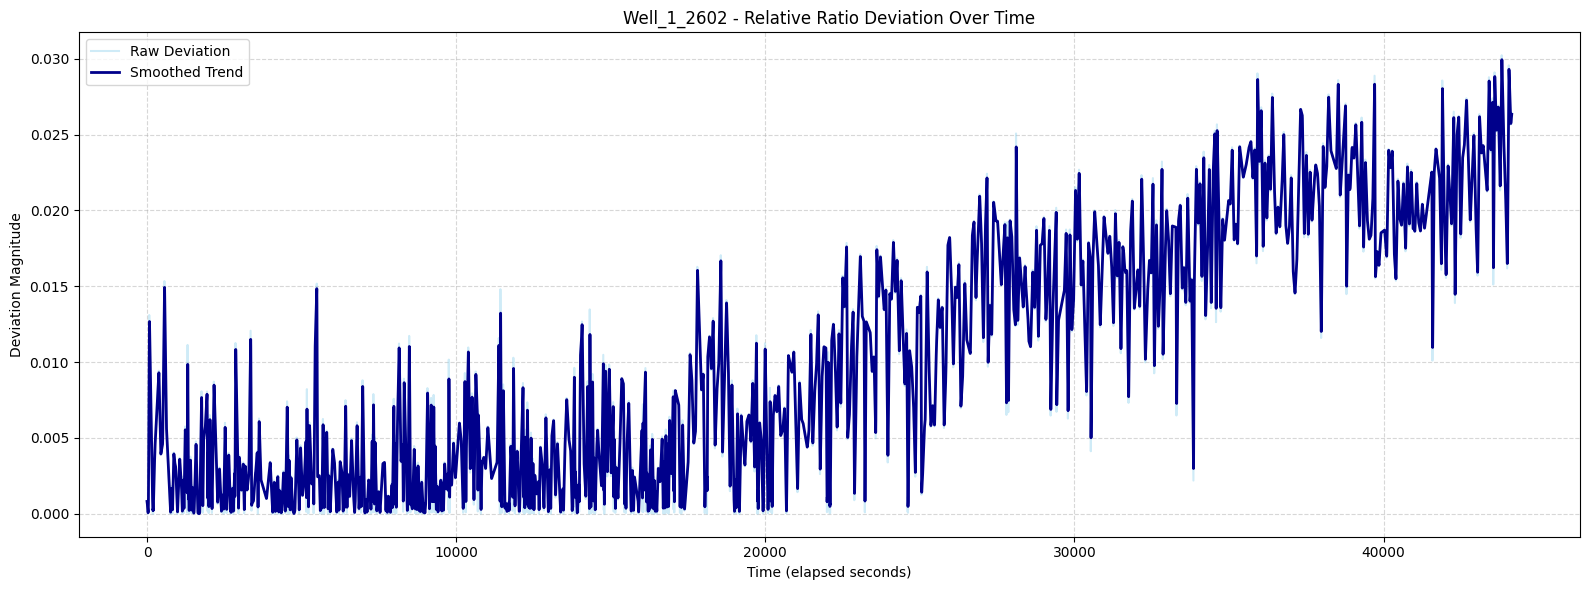

In [171]:
plot_rdd(tmp)

In [172]:
def plot_anomaly(df):
    fig, ax = plt.subplots(figsize=(16, 6))

    x_axis = df['elapsed_seconds']

    ax.plot(x_axis, df['anomaly_score'], color='skyblue', alpha=0.4, label='anomaly score')

    smoothed = df['anomaly_score'].rolling(window=10, min_periods=1).mean()
    ax.plot(x_axis, smoothed, color='darkblue', linewidth=2, label='Smoothed Trend')

    ax.set_title(name + ' - Anomaly Score Over Time')
    ax.set_ylabel(' Magnitude')
    ax.set_xlabel('Time (elapsed seconds)')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'{path}_anomaly_score.png', dpi=300)
    plt.show()

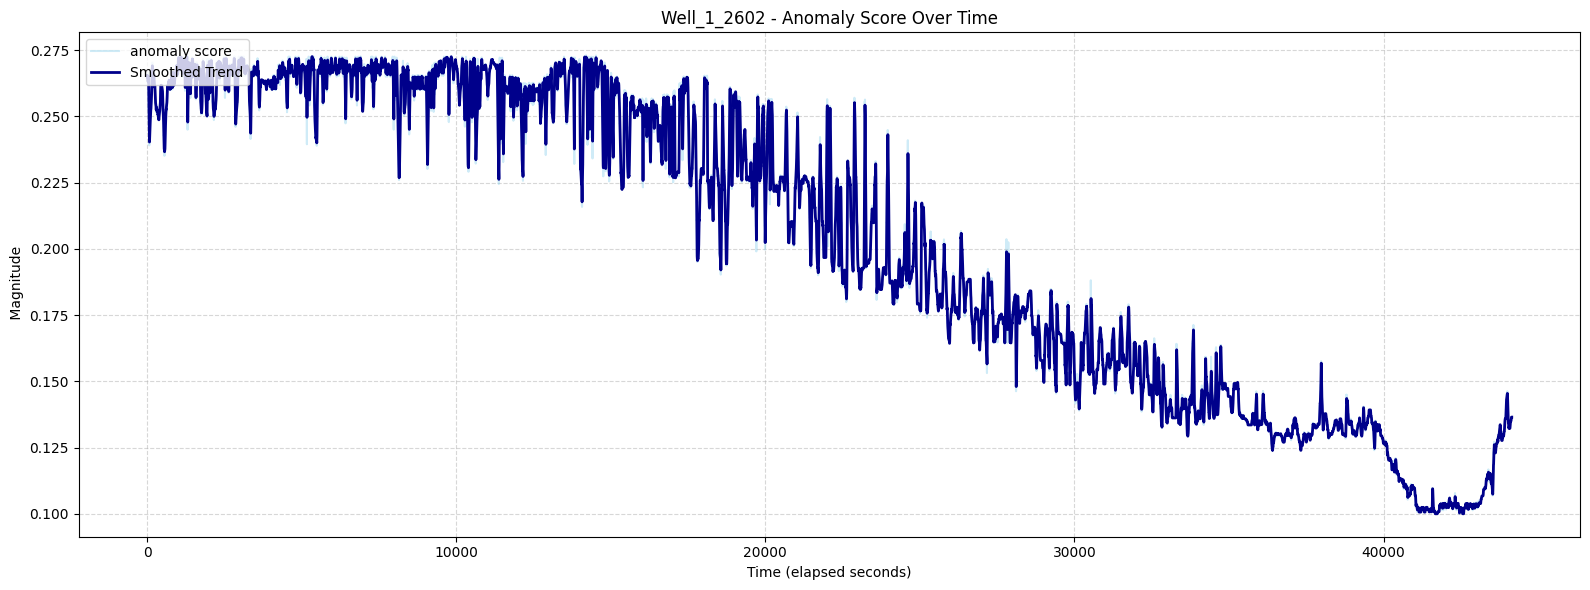

In [173]:
plot_anomaly(tmp)

In [174]:
def plot_pred(df):
    fig, ax = plt.subplots(figsize=(16, 6))

    x_axis = df['elapsed_seconds']

    ax.plot(x_axis, df['predicted_state'], color='skyblue', alpha=0.4, label='anomaly score')

    smoothed = df['predicted_state'].rolling(window=1, min_periods=1).mean()
    ax.plot(x_axis, smoothed, color='darkblue', linewidth=2, label='Smoothed Trend')

    ax.set_title('predicted label')
    ax.set_ylabel(' label')
    ax.set_xlabel('Time (elapsed seconds)')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'{path}_predicted_label.png', dpi=300)
    plt.show()

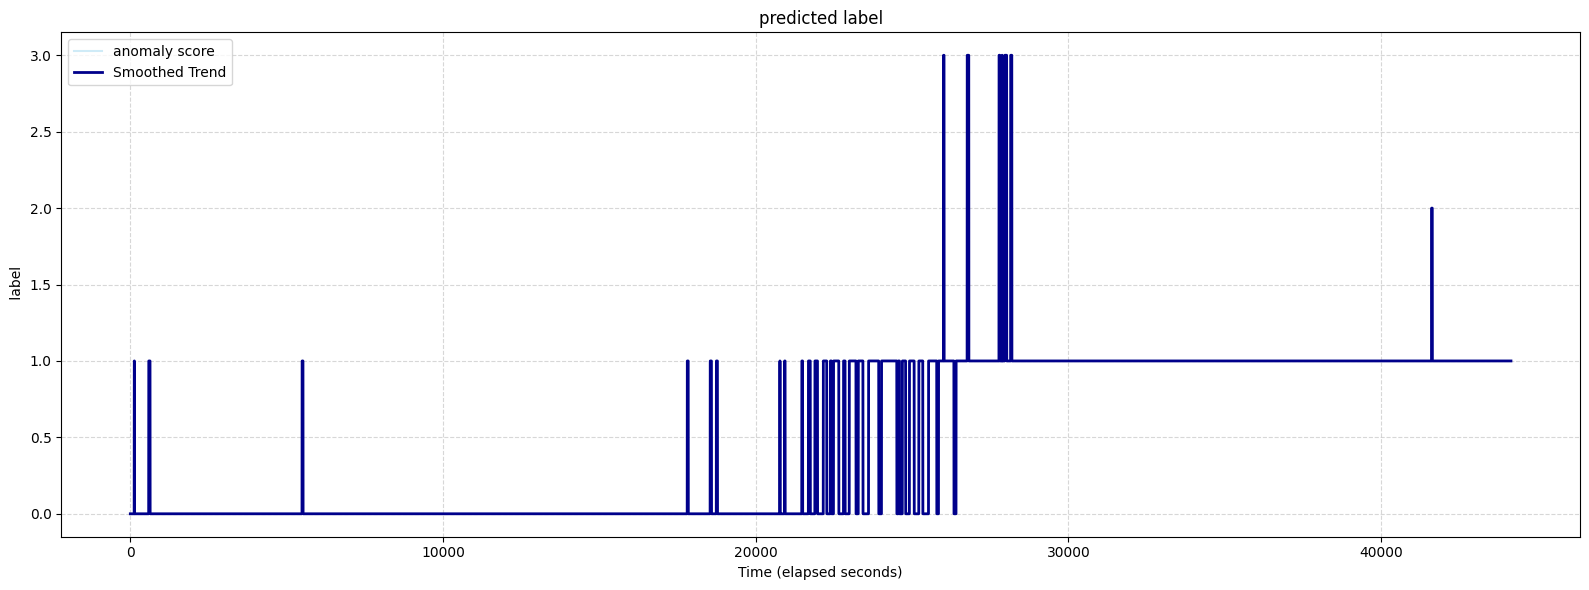

In [175]:
plot_pred(tmp)

In [176]:
def plot_class(df):
    fig, ax = plt.subplots(figsize=(16, 6))

    x_axis = df['elapsed_seconds']

    ax.plot(x_axis, df['class'], color='skyblue', alpha=0.4, label='anomaly score')

    smoothed = df['class'].rolling(window=1, min_periods=1).mean()
    ax.plot(x_axis, smoothed, color='darkblue', linewidth=2, label='Smoothed Trend')

    ax.set_title('actual label')
    ax.set_ylabel(' label')
    ax.set_xlabel('Time (elapsed seconds)')
    ax.grid(True, which='both', linestyle='--', alpha=0.5)
    ax.legend(loc='upper left')

    plt.tight_layout()
    plt.savefig(f'{path}_actual_label.png', dpi=300)
    plt.show()

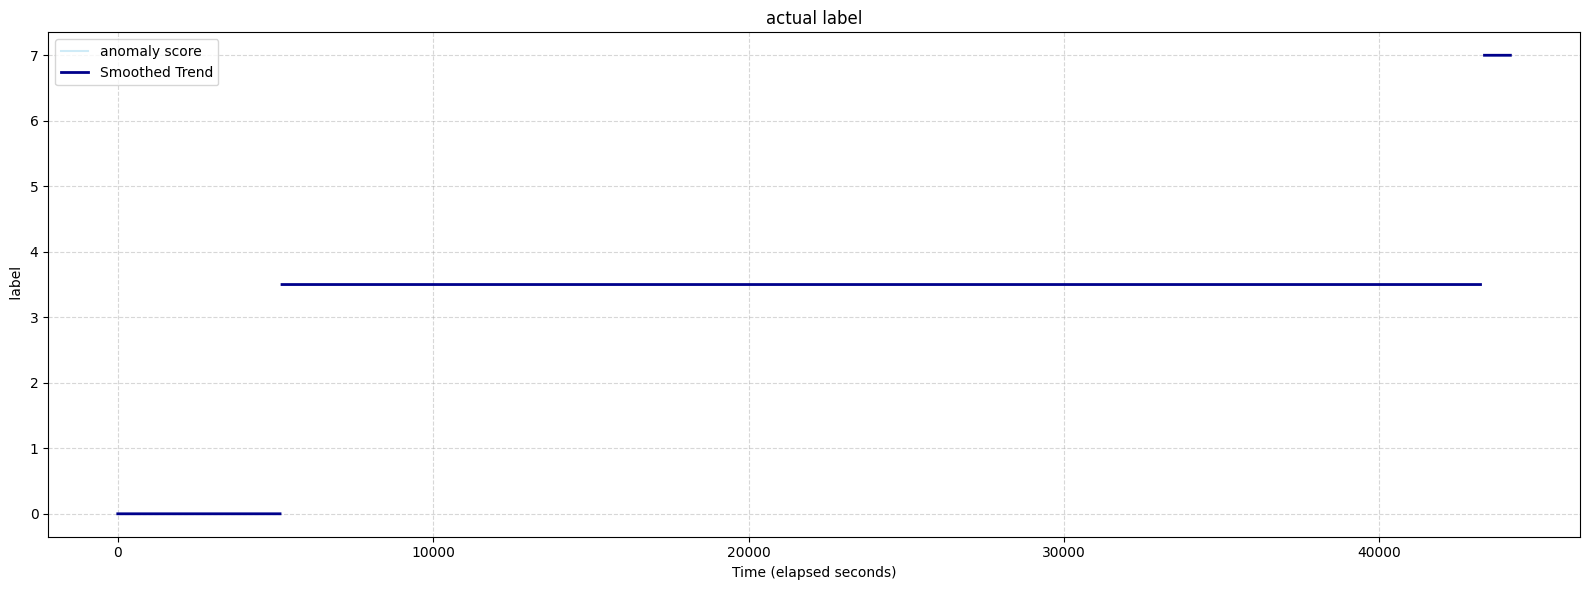

In [177]:
plot_class(tmp)